### data cleaning

In [1]:
import pandas as pd

# read data
df = pd.read_excel('/content/satisfaction.xlsx')  # 如果是csv就改成 read_csv

# 1. first five rows
print("First 5 rows:")
display(df.head())

# 2. data shape
print("\nShape of dataset:")
print(df.shape)

# 3. column
print("\nColumns:")
print(df.columns)

# 4. data type
print("\nData types:")
print(df.dtypes)

# 5. statistic
print("\nSummary statistics:")
display(df.describe())

# 6. null value
print("\nMissing values:")
print(df.isnull().sum())

#
print("\nUnique values in categorical columns:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"\n{col}:")
    print(df[col].unique())

First 5 rows:


,id,satisfaction_v2,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,11112,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,110278,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,103199,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,47462,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,120011,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,...,4,2,2,0,2,4,2,5,0,0.0



Shape of dataset:
(129880, 24)

Columns:
Index(['id', 'satisfaction_v2', 'Gender', 'Customer Type', 'Age',
       'Type of Travel', 'Class', 'Flight Distance', 'Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink', 'Gate location',
       'Inflight wifi service', 'Inflight entertainment', 'Online support',
       'Ease of Online booking', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes'],
      dtype='object')

Data types:
id                                     int64
satisfaction_v2                       object
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Seat comfort                           int64
Departure

,id,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,64940.500000,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,37493.270818,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,1.000000,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32470.750000,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,64940.500000,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,97410.250000,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,129880.000000,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000



Missing values:
id                                     0
satisfaction_v2                        0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393

### random forest

In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [6]:
# 1. read data
df = pd.read_excel('/content/satisfaction.xlsx')

# 2. delete useles columns
df = df.drop(columns=['id'])

# 3. define target and features
target = 'satisfaction_v2'
X = df.drop(columns=[target])
y = df[target]

# 4. spilit numeric and categorical features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Numeric features:")
print(list(numeric_features))
print("\nCategorical features:")
print(list(categorical_features))

# 5. handling missing value
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# 6. One-hot encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 7. preporocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Numeric features:
['Age', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

Categorical features:
['Gender', 'Customer Type', 'Type of Travel', 'Class']


In [7]:
# 8. random forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

# 9. set up whole pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

# 10. spilit train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 11. train the model
model.fit(X_train, y_train)

# 12. predict
y_pred = model.predict(X_test)

# 13. evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 0.9595780720665229

Classification Report:
                         precision    recall  f1-score   support

neutral or dissatisfied       0.95      0.96      0.96     11759
              satisfied       0.97      0.96      0.96     14217

               accuracy                           0.96     25976
              macro avg       0.96      0.96      0.96     25976
           weighted avg       0.96      0.96      0.96     25976


Confusion Matrix:
[[11336   423]
 [  627 13590]]


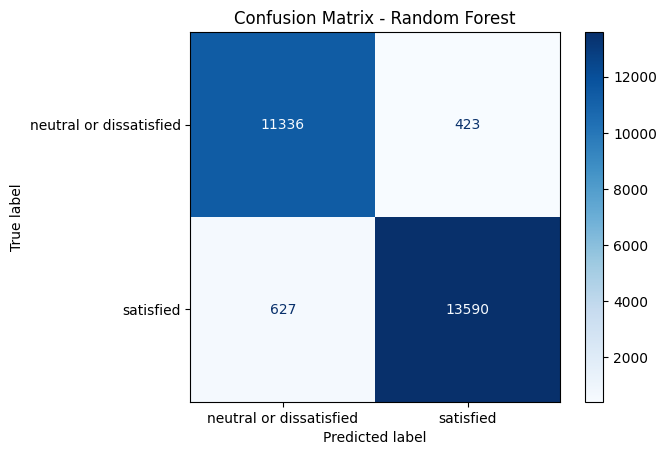


Top 15 Important Features:


,Feature,Importance
7,num__Inflight entertainment,0.198214
2,num__Seat comfort,0.123142
9,num__Ease of Online booking,0.079844
8,num__Online support,0.060581
4,num__Food and drink,0.037675
11,num__Leg room service,0.036518
15,num__Online boarding,0.033600
10,num__On-board service,0.032235
1,num__Flight Distance,0.031519
0,num__Age,0.028786


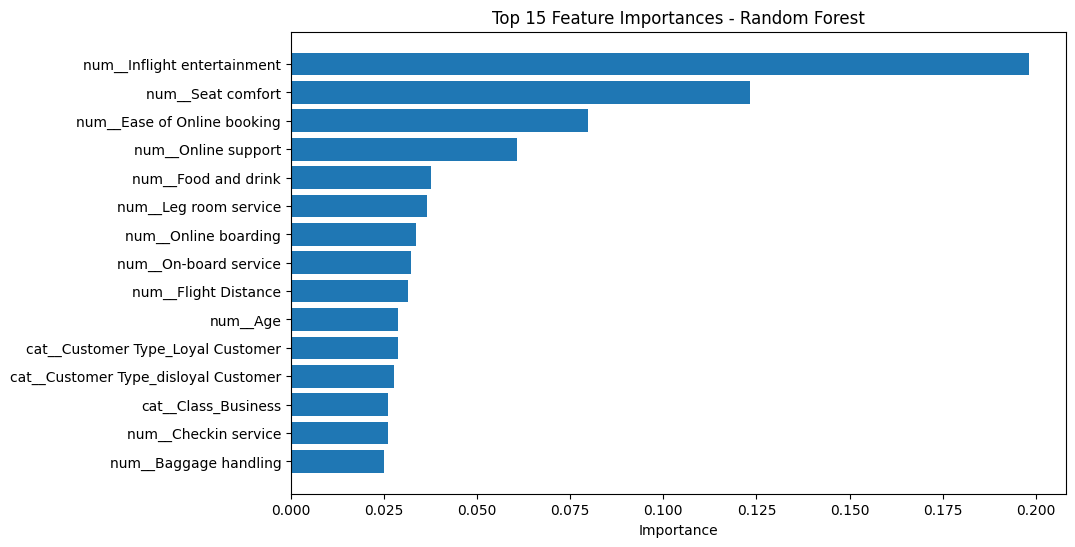

In [8]:
# 14. confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# 15. feature importance
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
importances = model.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 15 Important Features:")
display(feature_importance_df.head(15))

# 16. top 15
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'].head(15)[::-1],
         feature_importance_df['Importance'].head(15)[::-1])
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()


###hypothesis test

In [ ]:
### all test

In [29]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, chi2_contingency

target = "satisfaction_v2"

results = []

for col in df.columns:

    if col == target or col == "id":
        continue

    if df[col].dtype in ["int64", "float64"]:
        # numeric variables → t-test
        g1 = df[df[target] == "satisfied"][col].dropna()
        g2 = df[df[target] == "neutral or dissatisfied"][col].dropna()

        if len(g1) > 1 and len(g2) > 1:
            stat, p = ttest_ind(g1, g2, equal_var=False)
        else:
            p = np.nan

        test_type = "t-test"

    else:
        # category variables → chi-square
        table = pd.crosstab(df[col], df[target])

        if table.shape[0] > 1:
            stat, p, dof, exp = chi2_contingency(table)
        else:
            p = np.nan

        test_type = "chi-square"

    results.append({
        "variable": col,
        "test": test_type,
        "p_value": p
    })

results_df = pd.DataFrame(results)

# sort by p-value
results_df = results_df.sort_values("p_value")
results_df["p_value_scientific"] = results_df["p_value"].apply(lambda x: f"{x:.2e}" if pd.notnull(x) else x)

results_df

,variable,test,p_value,p_value_scientific
0,Gender,chi-square,0.000000e+00,0.00e+00
1,Customer Type,chi-square,0.000000e+00,0.00e+00
2,Age,t-test,0.000000e+00,0.00e+00
3,Type of Travel,chi-square,0.000000e+00,0.00e+00
4,Class,chi-square,0.000000e+00,0.00e+00
6,Seat comfort,t-test,0.000000e+00,0.00e+00
10,Inflight wifi service,t-test,0.000000e+00,0.00e+00
8,Food and drink,t-test,0.000000e+00,0.00e+00
14,On-board service,t-test,0.000000e+00,0.00e+00
13,Ease of Online booking,t-test,0.000000e+00,0.00e+00


In [33]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

target = "satisfaction_v2"

results = []

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:

    if col == "id":
        continue

    g1 = df[df[target] == "satisfied"][col].dropna()
    g2 = df[df[target] == "neutral or dissatisfied"][col].dropna()

    if len(g1) > 1 and len(g2) > 1:

        # Cohen's d
        mean_diff = g1.mean() - g2.mean()
        pooled_std = np.sqrt((g1.var() + g2.var()) / 2)
        cohens_d = mean_diff / pooled_std

    else:
        cohens_d = np.nan

    results.append({
        "variable": col,
        "cohens_d": cohens_d,
        "mean_satisfied": g1.mean(),
        "mean_neutral_or_dissatisfied": g2.mean()
    })

results_df = pd.DataFrame(results)

# sort by effect size
results_df = results_df.sort_values("cohens_d", key=abs, ascending=False)

results_df

,variable,cohens_d,mean_satisfied,mean_neutral_or_dissatisfied
7,Inflight entertainment,1.238914,4.024308,2.608644
9,Ease of Online booking,0.952507,3.984751,2.852261
8,Online support,0.846203,3.983260,2.959213
10,On-board service,0.751282,3.871946,2.973126
15,Online boarding,0.716862,3.751966,2.869695
11,Leg room service,0.639959,3.844247,3.052625
13,Checkin service,0.552161,3.645955,2.971850
12,Baggage handling,0.540741,3.969488,3.364601
14,Cleanliness,0.538110,3.977394,3.377324
2,Seat comfort,0.512135,3.145653,2.467335


In [32]:
from sklearn.metrics import roc_auc_score
import pandas as pd

# change satisfaction to 0/1
y = (df['satisfaction_v2'] == 'satisfied').astype(int)

# find all rating variables
rating_cols = [
    'Seat comfort',
    'Departure/Arrival time convenient',
    'Food and drink',
    'Gate location',
    'Inflight wifi service',
    'Inflight entertainment',
    'Online support',
    'Ease of Online booking',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Cleanliness',
    'Online boarding'
]

results = []

for col in rating_cols:

    auc = roc_auc_score(y, df[col])

    results.append({
        "variable": col,
        "AUC": auc,
        "mean_satisfied": df[df['satisfaction_v2']=='satisfied'][col].mean(),
        "mean_neutral": df[df['satisfaction_v2']=='neutral or dissatisfied'][col].mean()
    })

auc_df = pd.DataFrame(results)

auc_df = auc_df.sort_values("AUC", ascending=False)

auc_df

,variable,AUC,mean_satisfied,mean_neutral
5,Inflight entertainment,0.825507,4.024308,2.608644
7,Ease of Online booking,0.741788,3.984751,2.852261
6,Online support,0.726057,3.983260,2.959213
8,On-board service,0.701039,3.871946,2.973126
13,Online boarding,0.688343,3.751966,2.869695
9,Leg room service,0.673529,3.844247,3.052625
10,Baggage handling,0.659709,3.969488,3.364601
12,Cleanliness,0.657776,3.977394,3.377324
0,Seat comfort,0.648165,3.145653,2.467335
11,Checkin service,0.646928,3.645955,2.971850
